In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from pathlib import Path
from Bio import SeqIO, Align
import biotite.sequence.align as biotiteAlign
import biotite.sequence.io.fasta as fasta
from biotite.sequence import NucleotideSequence
import time
import concurrent.futures
from scipy.spatial.distance import hamming
from scipy.spatial.distance import pdist, squareform
from scipy import stats

# Pairwise embedding distances

In [2]:
def embeddingReader(path):
    embeddings = []
    with open(path, 'r+') as f:
        embeddings = eval(f.read())
    return np.array(embeddings)

In [3]:
def euclid(path, modelName, start):
    embeddings = embeddingReader(path)
    fileName = path.split('\\')[-1]
    alignment = squareform(pdist(embeddings, "euclidean"))
    embeddingAlignmentScores = pd.DataFrame(alignment)
    embeddingAlignmentScores.to_csv(f"100_genes_embeddings_distances/{modelName}/{fileName}_euclidDistances.csv", index=False)
    print(f"Processed {fileName} in {time.time() - start} seconds.")

In [4]:
models = [
    "LongSafari/hyenadna-medium-450k-seqlen-hf",
    "LongSafari/hyenadna-large-1m-seqlen-hf",
    "AIRI-Institute/gena-lm-bigbird-base-t2t",
    "songlab/gpn-brassicales",
    "InstaDeepAI/nucleotide-transformer-500m-human-ref",
    "PoetschLab/GROVER",
]

In [5]:
for model in models:
    modelName = model.split('/')[-1]
    print(f"Now doing {modelName}.")
    os.makedirs(f"100_genes_embeddings_distances/{modelName}/", exist_ok=True)
    start = time.time()
    for filename in Path(f"100_genes_embeddings/{modelName}/").glob("*_embeddings.txt"):
        euclid(str(filename), modelName, start)
    end = time.time()
    print(f"Done with {modelName}'s embeddings in {end - start} seconds.")

Now doing hyenadna-medium-450k-seqlen-hf.
Processed YAL015C_1200_embeddings.txt in 1.5399045944213867 seconds.
Processed YAL056C-A_351_embeddings.txt in 2.8645308017730713 seconds.
Processed YAL060W_1149_embeddings.txt in 4.092950105667114 seconds.
Processed YAR064W_300_embeddings.txt in 5.4133830070495605 seconds.
Processed YBL003C_399_embeddings.txt in 6.7484352588653564 seconds.
Processed YBL006W-A_150_embeddings.txt in 8.009614706039429 seconds.
Processed YBL038W_699_embeddings.txt in 9.506530046463013 seconds.
Processed YBL071C-B_99_embeddings.txt in 11.103026866912842 seconds.
Processed YBL071W-A_249_embeddings.txt in 13.616223812103271 seconds.
Processed YBL075C_1950_embeddings.txt in 16.184102058410645 seconds.
Processed YBL086C_1401_embeddings.txt in 18.645168781280518 seconds.
Processed YBR018C_1101_embeddings.txt in 20.886465072631836 seconds.
Processed YBR019C_2100_embeddings.txt in 23.290854930877686 seconds.
Processed YBR023C_3498_embeddings.txt in 25.801026582717896 seco

# Euclidean-hamming correlation

In [6]:
def evaluateScoreCorr(path, modelName, seqName, start):
    modelScores = pd.read_csv(path)
    seqScores = pd.read_csv(f"100_genes_hamming_distances_6/{seqName}_alignmentScores.csv")
    corr = modelScores.corrwith(seqScores)
    print(f"Processed {path} in {time.time() - start} seconds.")
    return corr

In [7]:
allCorrs = {}
allAveragedCorrs = {}

In [8]:
for model in models:
    modelName = model.split('/')[-1]
    geneCorrs = {}
    avgCorrs = {}
    print(f"Now doing {modelName}.")
    start = time.time()
    for filename in Path(f"100_genes_embeddings_distances/{modelName}/").glob("*.csv"):
        seqName = str(filename).split('\\')[-1].rstrip('_embeddings.txt_euclidDistances.csv')
        corrs = evaluateScoreCorr(str(filename), modelName, seqName, start)
        geneCorrs[seqName] = corrs
        avgCorrs[seqName] = corrs.mean()
    allCorrs[model] = geneCorrs
    allAveragedCorrs[model] = avgCorrs

Now doing hyenadna-medium-450k-seqlen-hf.
Processed 100_genes_embeddings_distances\hyenadna-medium-450k-seqlen-hf\YAL015C_1200_embeddings.txt_euclidDistances.csv in 0.698765754699707 seconds.
Processed 100_genes_embeddings_distances\hyenadna-medium-450k-seqlen-hf\YAL056C-A_351_embeddings.txt_euclidDistances.csv in 1.2841801643371582 seconds.
Processed 100_genes_embeddings_distances\hyenadna-medium-450k-seqlen-hf\YAL060W_1149_embeddings.txt_euclidDistances.csv in 1.9537718296051025 seconds.
Processed 100_genes_embeddings_distances\hyenadna-medium-450k-seqlen-hf\YAR064W_300_embeddings.txt_euclidDistances.csv in 2.579216241836548 seconds.
Processed 100_genes_embeddings_distances\hyenadna-medium-450k-seqlen-hf\YBL003C_399_embeddings.txt_euclidDistances.csv in 3.3968963623046875 seconds.
Processed 100_genes_embeddings_distances\hyenadna-medium-450k-seqlen-hf\YBL006W-A_150_embeddings.txt_euclidDistances.csv in 3.9534177780151367 seconds.
Processed 100_genes_embeddings_distances\hyenadna-medi

In [9]:
with open('finalCorrelations.txt', 'w+') as f:
    f.write(str(allCorrs))  

with open('averagedCorrelations.txt', 'w+') as f:
    f.write(str(allAveragedCorrs))  

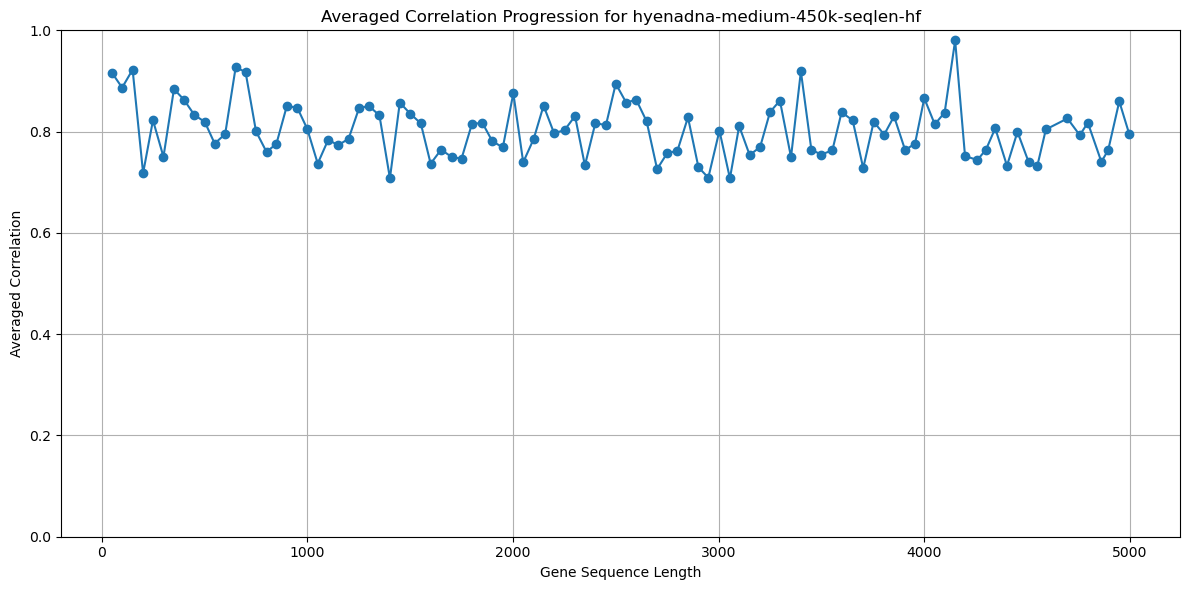

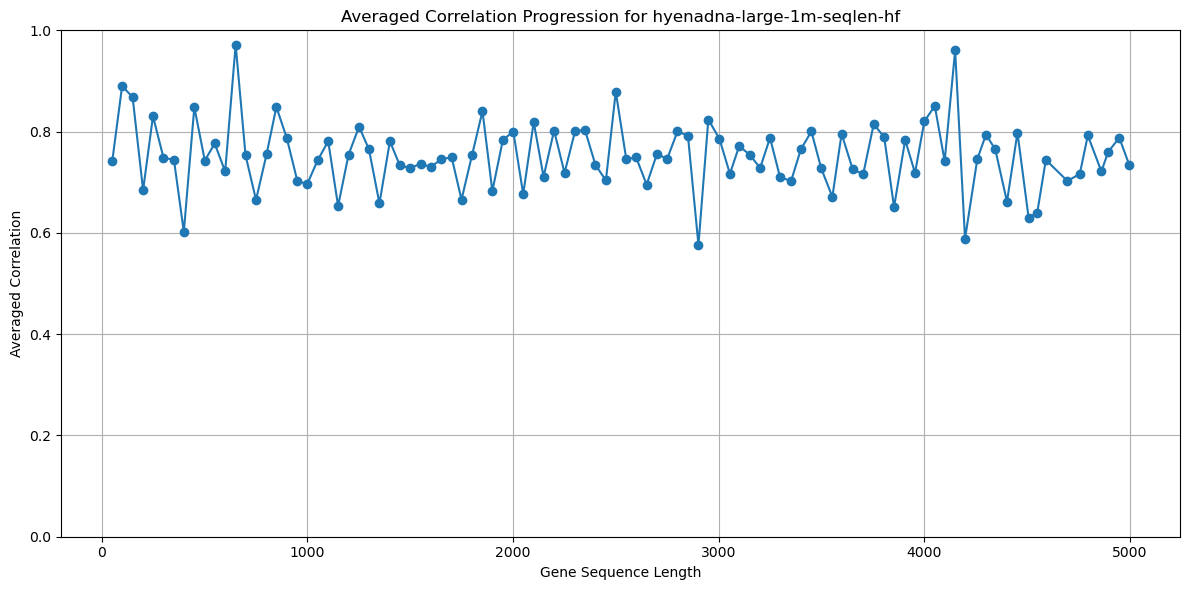

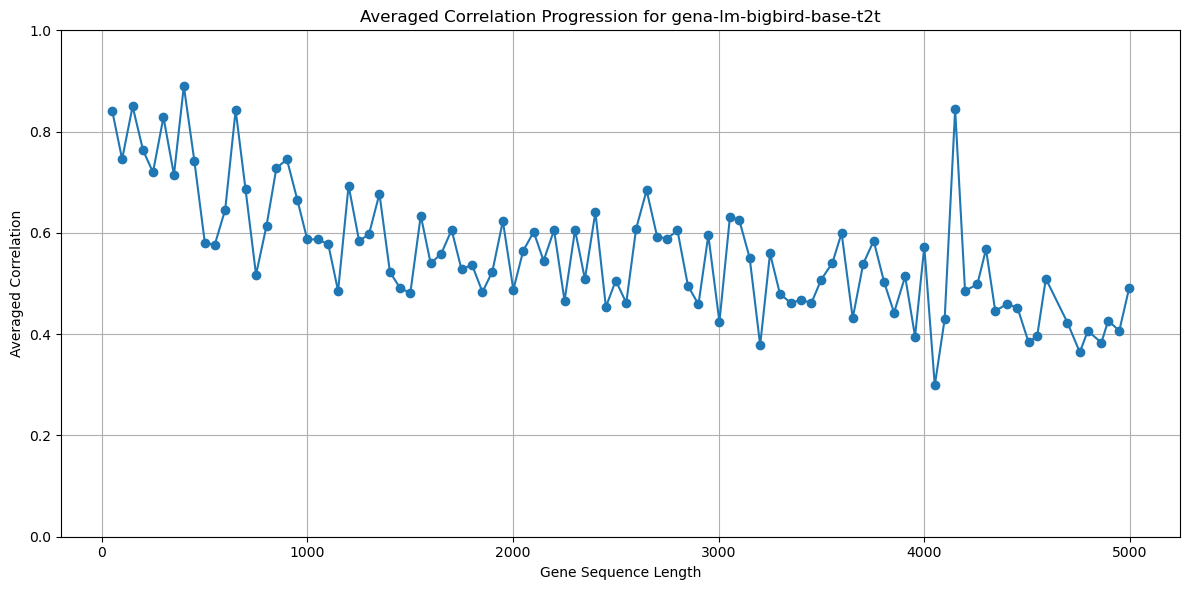

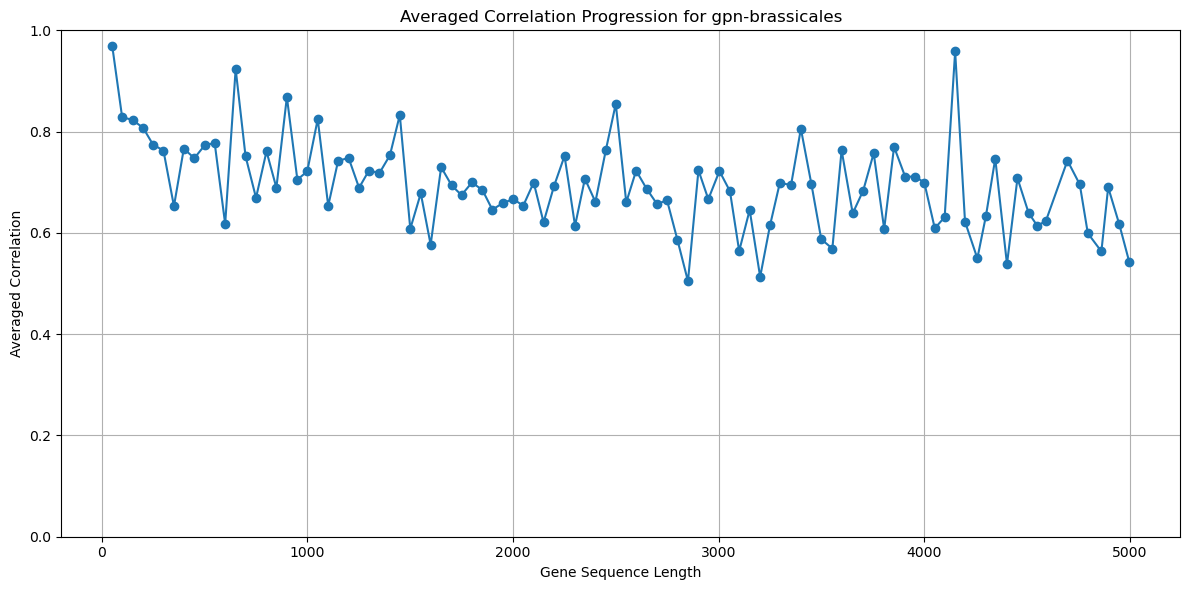

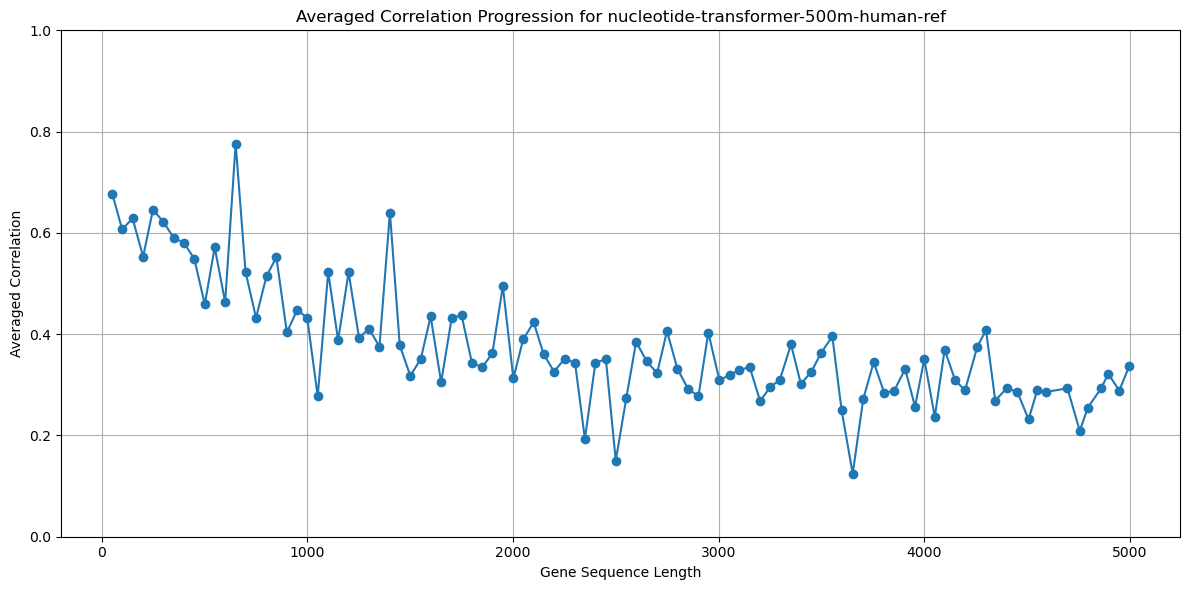

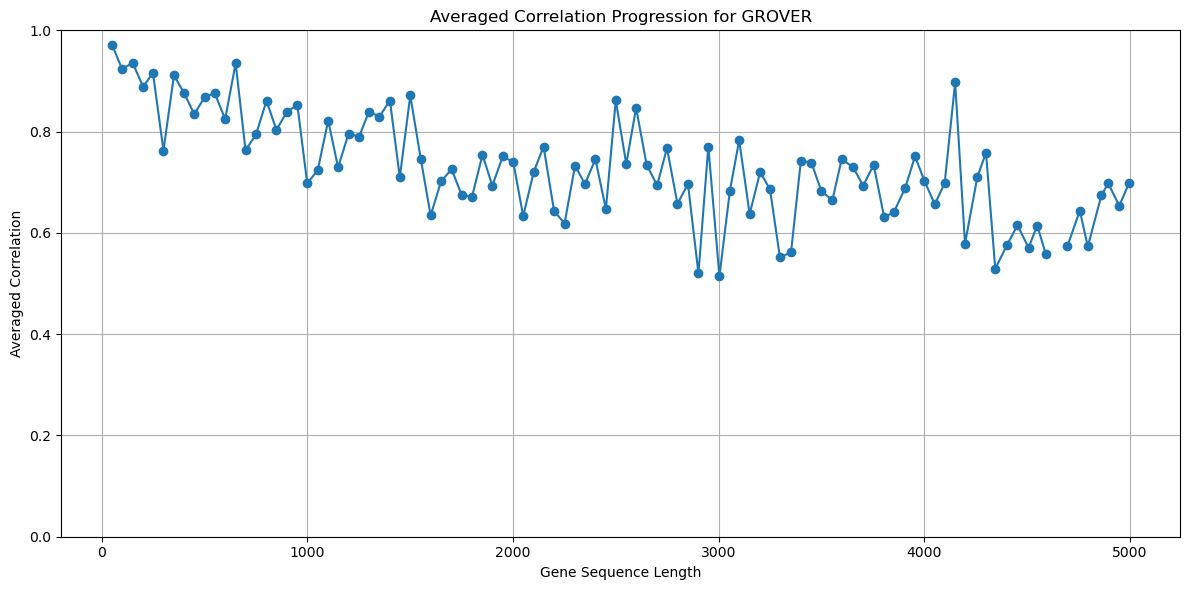

In [10]:
import matplotlib.pyplot as plt
import re
def extract_length(gene_name):
    match = re.search(r'_(\d+)$', gene_name)
    return int(match.group(1)) if match else None

outlier_genes = {}
for model, gene_corrs in allAveragedCorrs.items():
    model_name = model.split('/')[-1]
    if model_name != 'GROVER': 
        max_gene = max(gene_corrs, key=gene_corrs.get)
        outlier_genes[model] = max_gene

for model, gene_corrs in allAveragedCorrs.items():
    filtered_gene_corrs = {gene: corr for gene, corr in gene_corrs.items() 
                          if gene != outlier_genes.get(model)}
    
    data = [(gene, extract_length(gene), corr) for gene, corr in filtered_gene_corrs.items()]
    data_sorted = sorted(data, key=lambda x: x[1])
    gene_names = [item[0] for item in data_sorted]
    gene_lengths = [item[1] for item in data_sorted]
    corrs_sorted = [item[2] for item in data_sorted]
    plt.figure(figsize=(12, 6))
    plt.plot(gene_lengths, corrs_sorted, marker='o')
    
    model_name = model.split('/')[-1]
    plt.title(f'Averaged Correlation Progression for {model_name}')
    plt.xlabel('Gene Sequence Length')
    plt.ylabel('Averaged Correlation')
    plt.ylim(0, 1)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

seaborm lmplot

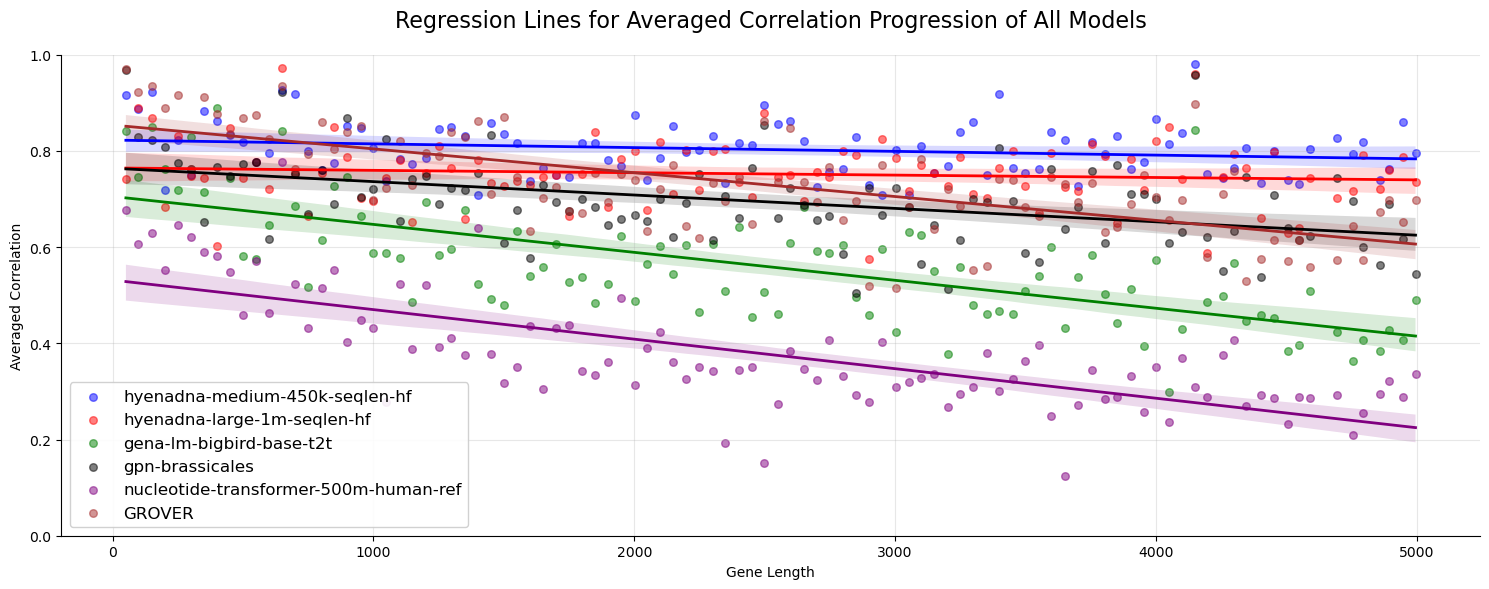

In [13]:
import seaborn as sns

# Prepare data for seaborn lmplot
plot_data = []

outlier_genes = {}
for model, gene_corrs in allAveragedCorrs.items():
    model_name = model.split('/')[-1]
    if model_name != 'GROVER':
        max_gene = max(gene_corrs, key=gene_corrs.get)
        outlier_genes[model] = max_gene

for model, gene_corrs in allAveragedCorrs.items():
    filtered_gene_corrs = {gene: corr for gene, corr in gene_corrs.items() 
                          if gene != outlier_genes.get(model)}
    
    model_name = model.split('/')[-1]
    
    for gene, corr in filtered_gene_corrs.items():
        length = extract_length(gene)
        if length is not None:
            plot_data.append({
                'Gene Length': length,
                'Averaged Correlation': corr,
                'Model': model_name
            })

df_plot = pd.DataFrame(plot_data)

# Create seaborn lmplot with regression lines
g = sns.lmplot(
    data=df_plot,
    x='Gene Length',
    y='Averaged Correlation',
    hue='Model',
    palette=['blue', 'red', 'green', 'black', 'purple', 'brown'],
    height=6,
    aspect=2.5,
    scatter_kws={'alpha': 0.5, 's': 30},
    line_kws={'linewidth': 2},
    ci=95,
    legend=False
)

g.set(ylim=(0, 1))
plt.title('Regression Lines for Averaged Correlation Progression of All Models', fontsize=16, pad=20)
plt.grid(True, alpha=0.3)

# Add legend at bottom-left with larger font
plt.legend(loc='lower left', fontsize=12, framealpha=0.9)

plt.tight_layout()
plt.show()


In [12]:
# Find gene with maximum correlation for each model
max_corr_genes = {}

for model, gene_corrs in allAveragedCorrs.items():
    # Find the gene with maximum correlation
    max_gene = max(gene_corrs, key=gene_corrs.get)
    max_corr_value = gene_corrs[max_gene]
    
    model_name = model.split('/')[-1]
    max_corr_genes[model_name] = {
        'gene': max_gene,
        'correlation': max_corr_value
    }
    
    print(f"{model_name}: Gene {max_gene} with correlation {max_corr_value:.4f}")

print("\nSummary:")
for model_name, info in max_corr_genes.items():
    print(f"{model_name}: {info['gene']} ({info['correlation']:.4f})")

hyenadna-medium-450k-seqlen-hf: Gene YIL173W_4650 with correlation 1.0000
hyenadna-large-1m-seqlen-hf: Gene YIL173W_4650 with correlation 1.0000
gena-lm-bigbird-base-t2t: Gene YIL173W_4650 with correlation 1.0000
gpn-brassicales: Gene YIL173W_4650 with correlation 1.0000
nucleotide-transformer-500m-human-ref: Gene YIL173W_4650 with correlation 1.0000
GROVER: Gene YJR151W-A_51 with correlation 0.9706

Summary:
hyenadna-medium-450k-seqlen-hf: YIL173W_4650 (1.0000)
hyenadna-large-1m-seqlen-hf: YIL173W_4650 (1.0000)
gena-lm-bigbird-base-t2t: YIL173W_4650 (1.0000)
gpn-brassicales: YIL173W_4650 (1.0000)
nucleotide-transformer-500m-human-ref: YIL173W_4650 (1.0000)
GROVER: YJR151W-A_51 (0.9706)
